# Netflix Content Analysis
**Analyst:** Kushagra Yadav

**Date:** July 2026

**Dataset:** 8,807 Netflix titles | 2008-2021

## Objective
To analyze Netflix's content library and uncover key insights around content type distribution, country-wise production, genre trends, and yearly growth - with actionable recommendations for content strategy.

## Tools Used
Python (Pandas, Matplotlib, Seaborn) | SQL (SQLite) | Power BI | Excel | Git

---
## Importing Libraries and Loading dataset

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("netflix_titles.xlsx")

print("Shape:", df.shape)
print("\nColumns:",list(df.columns))
print("\nData Types:")
print(df.dtypes)
df.head()

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
### Checking for the missing values

In [3]:
print("Missing values:")
print(df.isnull().sum())

#missing value percentage
print("\nMissing percentage:")
print(round(df.isnull().sum()/len(df)*100, 2))

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing percentage:
show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64


> *Correcting the missing values in the Data Cleaning section!*

---
## Checking the content type breakdown

In [7]:
print("Content Type Breakdown:")
print(df['type'].value_counts())

print("\nPercentage:")
print(round(df['type'].value_counts()/len(df)*100, 2))

Content Type Breakdown:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Percentage:
type
Movie      69.62
TV Show    30.38
Name: count, dtype: float64


---
## Checking year range

In [17]:
print("Year Range:")
print("Oldest content:", df['release_year'].min())
print("Newest content:", df['release_year'].max())

print("\nContent added to netflix (date_added sample):")
print(df['date_added'].dropna().head(5))

Year Range:
Oldest content: 1925
Newest content: 2021

Content added to netflix (date_added sample):
0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
Name: date_added, dtype: object


---

## Business Questions this Project will Answer

1. Which country produces the most Netflix content?
2. What is the ratio of Movies vs TV Shows on Netflix?
3. Which genres dominate the Netflix library?
4. How has Netflix grown its content library year over year - especially during COVID (2019-2021)?
5. What content ratings are most common and what does that say about Netflix's target audience?

---
**1. Why did i choose "fill" for some and "drop rows" for others?**

Some columns(director) is not important because **director** -> 29.91% missing value -> fill "Unknown" -> not used in analysis but kept for completeness.
Some columns(cast, country, rating, duration, date_added) are very important for the analysis and these columns are important because:
- **cast** -> 9% missing -> fill "Unknown" -> not directly used in business questions.
- **country** -> 9% missing -> fill "Unknown" -> *CRITICAL* - needed for top countries.
- **date_added** -> 0.11% missing -> drop those 10 rows -> tiny amount, won't affect analysis.
- **rating** -> 0.05% missing -> drop those 4 rows -> tiny amount, won't affect analysis.
- **duration** -> 0.03% missing -> drop those 3 rows -> tiny amount, won't affect analysis.


**2. For each null column - why did i choose fill vs drop? What percentage threshold makes dropping rows acceptable vs unacceptable?**

**NULL HANDLING STRATEGY**
- Rule 1: If null % is above 5% AND column is important -> fill with "Unknown"
- Rule 2: If null % is below 1% -> drop those rows safely (minimal data loss)
- Rule 3: If column is not used in any business question -> fill "Unknown" and ignore

**Applied to this dataset:**
- director  -> 29.91% missing -> fill "Unknown" (not used in analysis)
- cast      -> 9.37%  missing -> fill "Unknown" (not used in analysis)
- country   -> 9.44%  missing -> fill "Unknown" (used in Q1 - handle carefully)
- date_added-> 0.11%  missing -> drop 10 rows  (safe - only 10 rows lost)
- rating    -> 0.05%  missing -> drop 4 rows   (safe - only 4 rows lost)
- duration  -> 0.03%  missing -> drop 3 rows   (safe - only 3 rows lost)
---

# Data Cleaning

In [20]:
import pandas as pd
import numpy as np

df = pd.read_excel("netflix_titles.xlsx")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


---
## Structure Check 

In [22]:
print("Shape:", df.shape)
print("\n Data Types:")
print(df.dtypes)

Shape: (8807, 12)

 Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


---
## Duplicates checking

In [24]:
print("Duplicate rows:", df.duplicated().sum())
print("\nDuplicate titles:", df['title'].duplicated().sum())

Duplicate rows: 0

Duplicate titles: 3


In [26]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (8807, 12)


**Duplicate check result:** 0 fully duplicate rows found. 3 titles appear more than once - likely the same title released in different years/countries (e.g. a remake), not true duplicates. No rows dropped.

---
## Handling nulls in high-missing columns

In [35]:
# Filling high-missing columns with Unknown [director, cast, country]
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

print("Nulls after filling:")
print(df[['director','cast','country']].isnull().sum())

Nulls after filling:
director    0
cast        0
country     0
dtype: int64


In [37]:
# Dropping rows with tiny null counts
df = df.dropna(subset = ['date_added', 'rating', 'duration'])

print("Shape after dropping tiny nulls:", df.shape)
print("\nRemaining nulls:")
print(df.isnull().sum())

Shape after dropping tiny nulls: (8790, 12)

Remaining nulls:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


---
## Fixing columns 

In [39]:
print("Current data type of date_added:", df['date_added'].dtype)


df['date_added'] = pd.to_datetime(df['date_added'], errors = 'coerce')

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("Date Conversion done.")
print(df[['date_added','year_added','month_added']].head(5))

Current data type of date_added: object
Date Conversion done.
  date_added  year_added  month_added
0 2021-09-25      2021.0          9.0
1 2021-09-24      2021.0          9.0
2 2021-09-24      2021.0          9.0
3 2021-09-24      2021.0          9.0
4 2021-09-24      2021.0          9.0


In [41]:
# Check for hidden parsing failures after date conversion
print("Nulls in date_added after conversion:", df['date_added'].isnull().sum())
print(df[df['date_added'].isnull()][['title','date_added']])

Nulls in date_added after conversion: 88
                            title date_added
6079              Abnormal Summit        NaT
6177     å¿è€…ãƒãƒƒãƒˆãƒªãã‚“        NaT
6213                Bad Education        NaT
6279  Being Mary Jane: The Series        NaT
6304     Big Dreams, Small Spaces        NaT
...                           ...        ...
8539                   The Tudors        NaT
8557                The West Wing        NaT
8684                      Vroomiz        NaT
8712   Weird Wonders of the World        NaT
8755            Women Behind Bars        NaT

[88 rows x 2 columns]


In [43]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0


In [55]:
# Fixing duration column

df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)
df['duration_type'] = df['duration'].str.extract(r'([A-Za-z]+)')

print("Duration examples:")
print(df[['type','duration','duration_int','duration_type']].head(10))

Duration examples:
      type   duration  duration_int duration_type
0    Movie     90 min          90.0           min
1  TV Show  2 Seasons           2.0       Seasons
2  TV Show   1 Season           1.0        Season
3  TV Show   1 Season           1.0        Season
4  TV Show  2 Seasons           2.0       Seasons
5  TV Show   1 Season           1.0        Season
6    Movie     91 min          91.0           min
7    Movie    125 min         125.0           min
8  TV Show  9 Seasons           9.0       Seasons
9    Movie    104 min         104.0           min


In [72]:
print(df.shape)
df.head(2)

(8790, 17)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_int,duration_type,genre
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0,min,[Documentaries]
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0,Seasons,"[International TV Shows, TV Dramas, TV Mysteries]"


---
## Explode genres column

In [64]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'year_added', 'month_added', 'duration_int', 'duration_type'],
      dtype='object')

In [66]:
# Splitting genres and exploding into separate rows
df['genre'] = df['listed_in'].str.split(', ')
df_genres = df.explode('genre')

print("Original shape:", df.shape)
print("After exploding genres:", df_genres.shape)
print("\nTop 10 genres:")
print(df_genres['genre'].value_counts().head(10))

Original shape: (8790, 17)
After exploding genres: (19294, 17)

Top 10 genres:
genre
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [179]:
print(type(df_genres['genre'].iloc[0]))
print(df_genres['genre'].head(10))

<class 'str'>
0             Documentaries
1    International TV Shows
1                 TV Dramas
1              TV Mysteries
2            Crime TV Shows
2    International TV Shows
2     TV Action & Adventure
3                Docuseries
3                Reality TV
4    International TV Shows
Name: genre, dtype: object


**Note:** genre column in df shows lists (pre-explode) - use df_genres for genre analysis df_genres confirmed working: type = str, properly exploded into 19,294 rows

---
## Checking for unique values

In [68]:
print("Content types:", df['type'].unique())
print("\nRatings:", df['rating'].unique())
print("\nTop 10 countries:")
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
print(top_countries)
print("\nYear added range:", df['year_added'].min(), "to", df['year_added'].max())

Content types: ['Movie' 'TV Show']

Ratings: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' 'NR' 'TV-Y7-FV' 'UR']

Top 10 countries:
country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Year added range: 2008.0 to 2021.0


**Note on country analysis:** 831 titles (9.4%) have missing country data, filled as "Unknown" earlier for dataset completeness. When ranking countries specifically for Business Question, these are excluded so a placeholder value never appears as a false "top country."

In [70]:
multi_country = df[df['country'].str.contains(',', na = False)]
print("Titles with multiple countries listed:", len(multi_country))
print(multi_country['country'].head(10))

Titles with multiple countries listed: 1320
7      United States, Ghana, Burkina Faso, United Kin...
12                               Germany, Czech Republic
29                          United States, India, France
38                          China, Canada, United States
46                    South Africa, United States, Japan
90                                  Spain, United States
94                         United Kingdom, United States
95                         United States, United Kingdom
99                                 France, United States
111                             United States, Singapore
Name: country, dtype: object


In [74]:
# Splitting and exploding country column (same technique as genre)
df['country_list'] = df['country'].str.split(', ')
df_countries = df.explode('country_list')

print("Original shape:", df.shape)
print("After exploding countries:", df_countries.shape)

Original shape: (8790, 18)
After exploding countries: (10828, 18)


*Use **df_countries** only for country-level analysis - other business questions should use the original **df** to avoid double-counting titles*

In [76]:
print("Top 10 countries (exploded, excluding Unknown):")
top_countries_real = df_countries[df_countries['country_list'] != 'Unknown']['country_list'].value_counts().head(10)
print(top_countries_real)

Top 10 countries (exploded, excluding Unknown):
country_list
United States     3680
India             1046
United Kingdom     803
Canada             445
France             393
Japan              316
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64


In [183]:
print(data['type'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


**Note on multi-country titles:** 1,320 titles (15%) list more than one country (co-productions). These were split and exploded so each contributing country gets proper credit, instead of being grouped under one combined string like "United States, India, France."

---
## Saving cleaned dataset

In [78]:
df.to_csv("Netflix_Cleaned.csv", index = False)
print("Cleaned file saved!")
print("Final shape:", df.shape)

Cleaned file saved!
Final shape: (8790, 18)


## Cleaning Summary
| Column     | Issue                    | Fix Applied                 |
|------------|--------------------------|-----------------------------|
| director   | 29.91% missing           | Filled with "Unknown"       |
| cast       | 9.37% missing            | Filled with "Unknown"       |
| country    | 9.44% missing            | Filled with "Unknown"       |
| date_added | 0.11% missing (10 rows)  | Dropped rows                |
| rating     | 0.05% missing (4 rows)   | Dropped rows                |
| duration   | 0.03% missing (3 rows)   | Dropped rows                |
| date_added | Stored as text           | Converted to datetime       |
| duration   | Mixed text + numbers     | Extracted numeric value     |
| listed_in  | Multiple genres per cell | Exploded into separate rows |

**Final clean dataset: Netflix_Cleaned.csv**

---
## Exploratory Data Analysis & Visualization

In [81]:
import matplotlib
matplotlib.rcdefaults()
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style = "whitegrid")

data = pd.read_csv("Netflix_Cleaned.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_int,duration_type,genre,country_list
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0,min,['Documentaries'],['United States']
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,2.0,Seasons,"['International TV Shows', 'TV Dramas', 'TV My...",['South Africa']
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,1.0,Season,"['Crime TV Shows', 'International TV Shows', '...",['Unknown']
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,1.0,Season,"['Docuseries', 'Reality TV']",['Unknown']
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,2.0,Seasons,"['International TV Shows', 'Romantic TV Shows'...",['India']


> *Loading from cleaned file — not from **df** variable above to ensure EDA always uses clean data regardless of run order*

In [83]:
### Recreate exploded dataframes needed for analysis
data['country_list'] = data['country'].str.split(', ')
df_countries = data.explode('country_list')

print("Data loaded: ", data.shape)
print("Countries exploded:", df_countries.shape)
print("Genre exploaded:", df_genres.shape)

Data loaded:  (8790, 18)
Countries exploded: (10828, 18)
Genre exploaded: (19294, 17)


---
### 1. Movie vs TV Shows

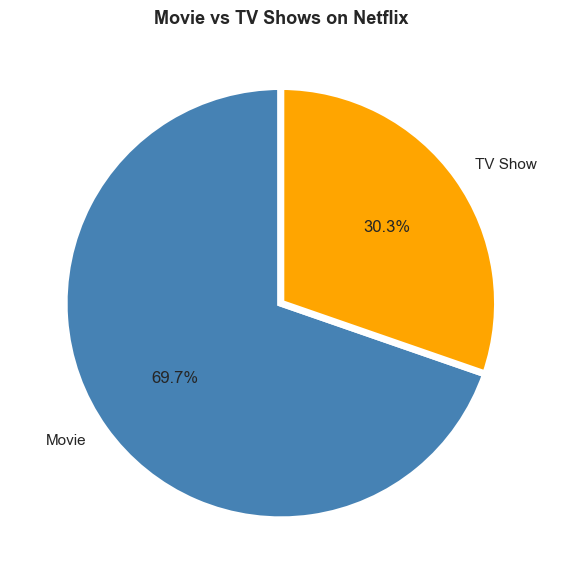

In [117]:
type_counts = data['type'].value_counts()

fig, ax = plt.subplots(figsize = (10, 6), dpi = 100)
colors = ['steelblue', 'orange']
ax.pie(type_counts.values,
       labels = type_counts.index,
       autopct = '%1.1f%%',
       colors = colors,
       startangle = 90,
       wedgeprops = {'edgecolor': 'white', 'linewidth': 5})

ax.set_title("Movie vs TV Shows on Netflix", fontsize = 13, fontweight = 'bold')
plt.tight_layout()
plt.savefig("charts/1_movies_vs_tvshows.png")
plt.show()

#### Business Insight - Movies vs TV Shows
**What:** Movies dominate Netflix's library at ~69.7%, TV Shows at ~30.3%

**Why it matters:** Netflix invests more in movies than series - but TV shows drive more watch time and subscriber retention per title

**Action:** Netflix should balance investment - TV shows create longer engagement loops that reduce subscriber churn

---
### 2. Top 10 Countries by Content

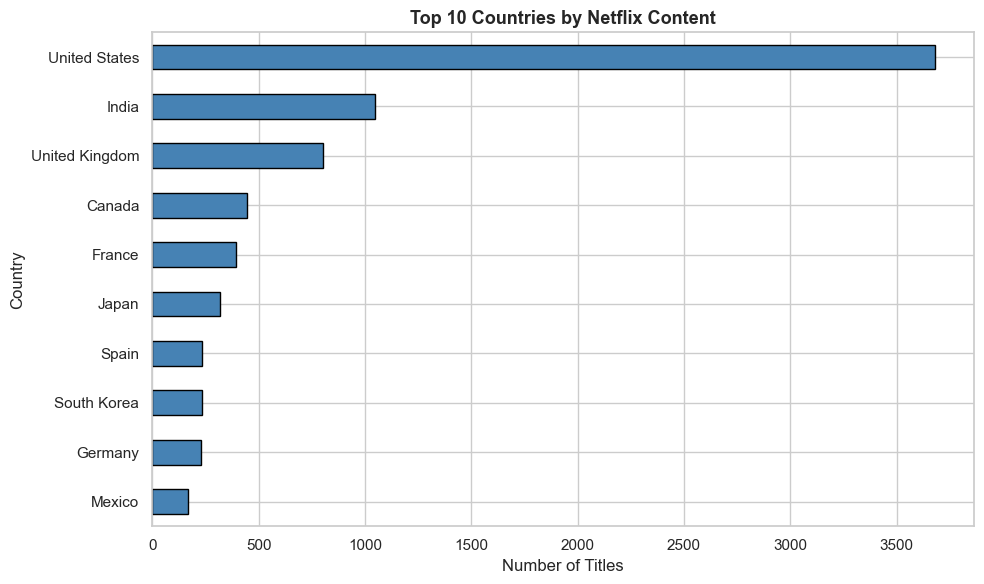

In [139]:
top_countries = df_countries[df_countries['country_list'] != 'Unknown']['country_list'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6), dpi = 100)
top_countries.plot(kind = 'barh', color = 'steelblue', edgecolor = 'black', ax = ax)

ax.set_title('Top 10 Countries by Netflix Content', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Country')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('charts/2_top_countries.png')
plt.show()

#### Business Insight - Top 10 Countries
**What:** United States leads with 3,680 titles. India 2nd (1,046). UK nearly doubled after counting co-productions properly (803)

**Why it matters:** Netflix's library is heavily US-centric - over 40% of all content involves US production

**Action:** To grow international subscribers, Netflix needs to invest more in local content beyond US and India

---
### 3. Top 10 Genres

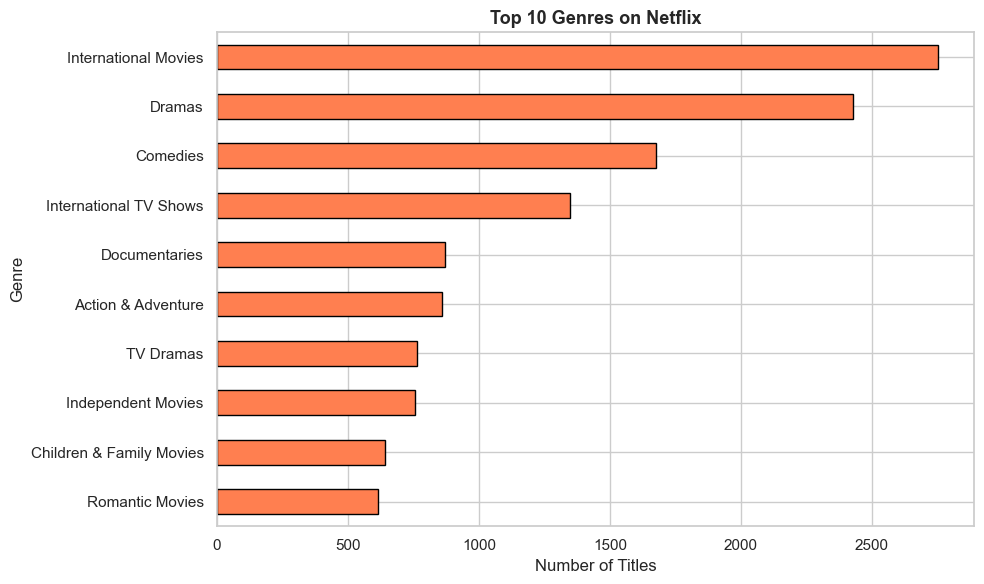

In [141]:
top_genres = df_genres['genre'].value_counts().head(10)

fig, ax = plt.subplots(figsize = (10, 6), dpi = 100)
top_genres.plot(kind = 'barh', color = 'coral', edgecolor = 'black', ax = ax)

ax.set_title('Top 10 Genres on Netflix', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Number of Titles')
ax.set_ylabel('Genre')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('charts/3_top_genres.png')
plt.show()

#### Business Insight - Top 10 Genres
**What:** International Movies top the list (2,752), followed by Dramas (2,426) and Comedies (1,674)

**Why it matters:** "International Movies" being #1 shows Netflix's global content strategy is working - non-English content is a major pillar

**Action:** Continue investing in international drama and comedy - these genres have universal appeal across markets

---
### 4. Yearly Content Growth

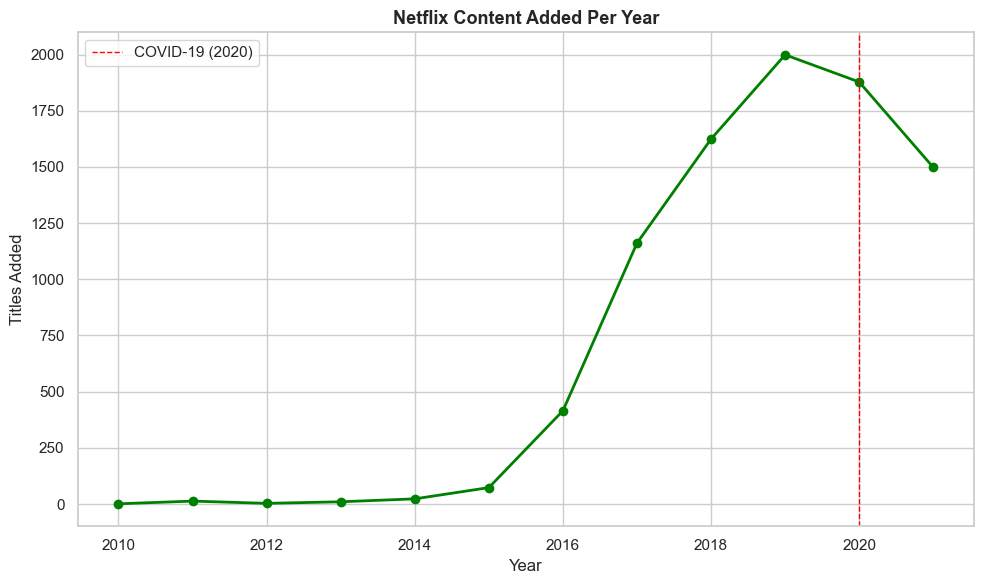

In [149]:
yearly = data.groupby('year_added')['show_id'].count().reset_index()
yearly.columns = ['year', 'count']
yearly = yearly[yearly['year'] >= 2010]

fig, ax = plt.subplots(figsize = (10, 6), dpi = 100)
ax.plot(yearly['year'], yearly['count'], color = 'green', linewidth = 2, marker = 'o')

ax.set_title('Netflix Content Added Per Year', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Year')
ax.set_ylabel('Titles Added')
ax.axvline(x = 2020, color = 'red', linestyle = '--', linewidth = 1, label = 'COVID-19 (2020)')
ax.legend()
plt.tight_layout()
plt.savefig('charts/4_yearly_growth.png')
plt.show()

#### Business Insight - Yearly Content Growth
**What:** Netflix peaked at 1,999 titles added in 2019. COVID caused a 6% drop in 2020 (1,878 titles) and a steeper 20% drop in 2021 (1,498 titles) as production delays hit harder post-lockdown

**Why it matters:** The 2021 drop is actually larger than 2020 - showing COVID's impact was delayed, not immediate. Productions shut down in 2020 couldn't release until 2021 or later

**Action:** Post-COVID content strategy should focus on rebuilding 2022–2023 pipeline, prioritizing international markets where local productions recovered faster than Hollywood

---
### 5. Content Ratings Distribution

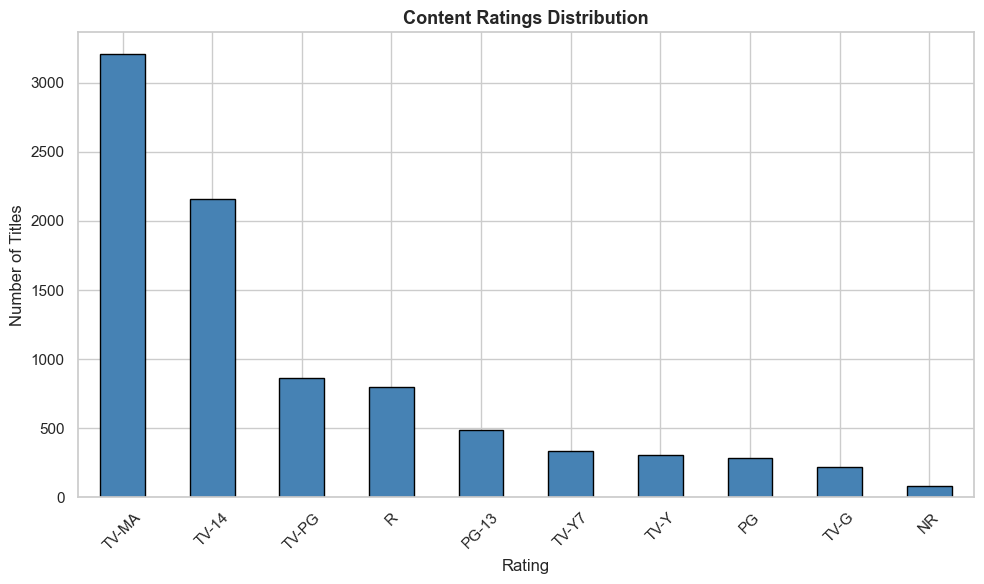

In [151]:
ratings = data['rating'].value_counts().head(10)

fig, ax = plt.subplots(figsize = (10, 6), dpi = 100)
ratings.plot(kind = 'bar', color = 'steelblue', edgecolor = 'black', ax = ax)

ax.set_title('Content Ratings Distribution', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Titles')
ax.tick_params(axis = 'x', rotation = 45)
plt.tight_layout()
plt.savefig('charts/5_ratings_distribution.png')
plt.show()

#### Business Insight - Content Ratings
**What:** TV-MA (mature audiences) dominates Netflix's library, followed by TV-14 and TV-PG

**Why it matters:** Netflix primarily targets adults (18+) - majority of content is rated for mature audiences

**Action:** To grow family and teen subscriber segments, Netflix needs more TV-G, TV-Y and TV-PG content

---
### 6. Movies vs TV Shows by Top 5 Countries

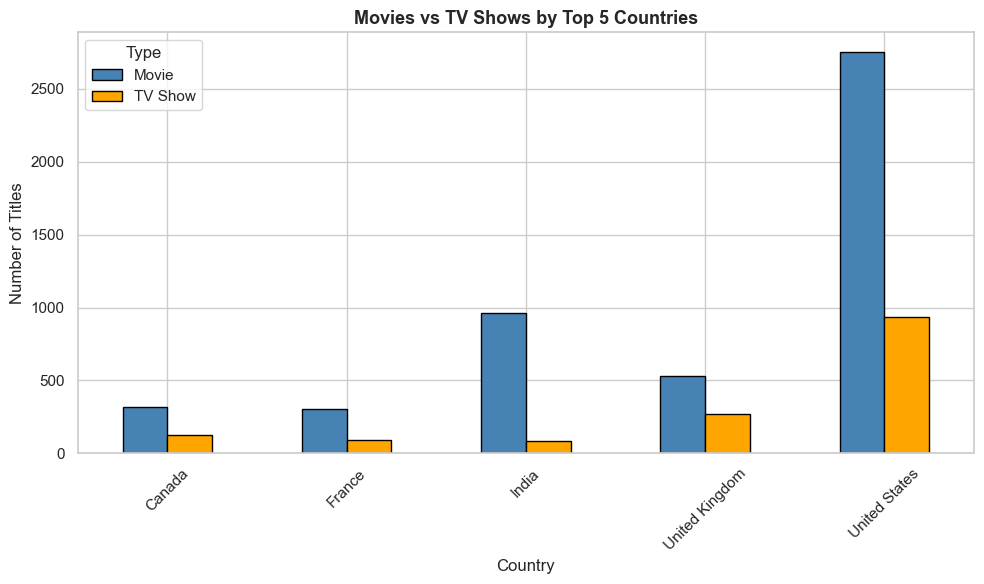

In [153]:
top5 = ['United States', 'India', 'United Kingdom', 'Canada', 'France']
country_type = df_countries[df_countries['country_list'].isin(top5)]
country_type_count = country_type.groupby(['country_list', 'type']).size().unstack()

fig, ax = plt.subplots(figsize = (10, 6), dpi = 100)
country_type_count.plot(kind = 'bar', ax = ax, color = ['steelblue', 'orange'], edgecolor = 'black')

ax.set_title('Movies vs TV Shows by Top 5 Countries', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Titles')
ax.tick_params(axis = 'x', rotation = 45)
ax.legend(title = 'Type')
plt.tight_layout()
plt.savefig('charts/6_country_type.png')
plt.show()

#### Business Insight - Content Type by Top 5 Countries
**What:** US and India heavily favor Movies over TV Shows. UK has a more balanced Movies/TV Shows split

**Why it matters:** Different countries have different content consumption patterns

**Action:** Netflix should tailor its recommendation algorithm by country - not use a one-size-fits-all approach

---
### 7. Monthly Content Addition Pattern

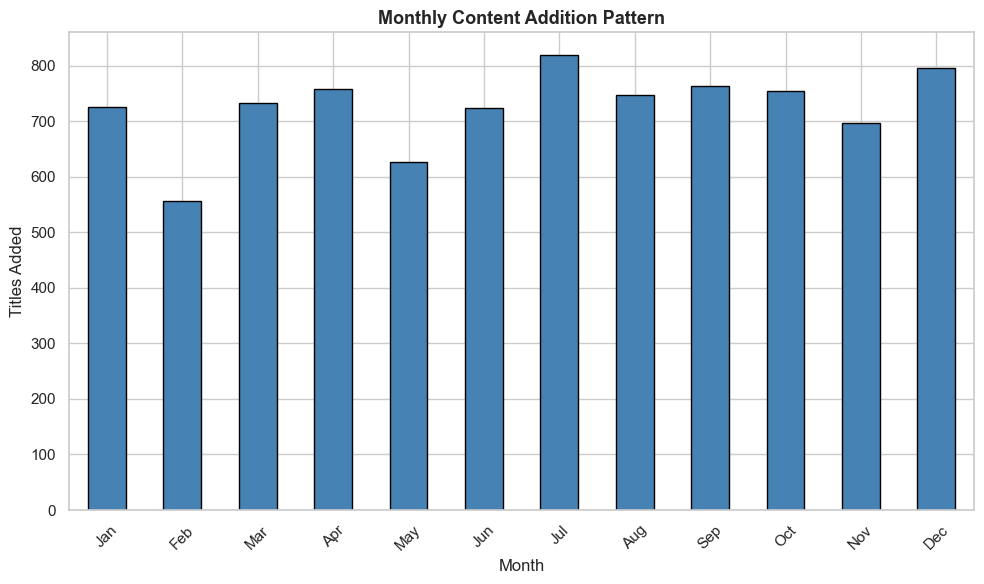

In [155]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = data.groupby('month_added')['show_id'].count()

fig, ax = plt.subplots(figsize = (10, 6), dpi = 100)
monthly.plot(kind = 'bar', color = 'steelblue', edgecolor = 'black', ax = ax)

ax.set_title('Monthly Content Addition Pattern', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Month')
ax.set_ylabel('Titles Added')
ax.set_xticklabels(months, rotation = 45)
plt.tight_layout()
plt.savefig('charts/7_monthly_pattern.png')
plt.show()

#### Business Insight - Monthly Patterns
**What:** Netflix adds most content in Q4 (Oct-Dec) - holiday season content push

**Why it matters:** Content additions are seasonal - Netflix bulks up its library before the holiday viewing period

**Action:** Subscribers should expect biggest content drops in Q4 - Netflix uses this to reduce churn during holiday season

---
### EDA Summary - Key Findings

1. **Content Mix:** Netflix is 69.7% Movies, 30.3% TV Shows

2. **Top Country:** United States leads with 3,680 titles (co-productions counted)

3. **Top Genre:** International Movies - showing Netflix's global strategy

4. **Growth:** Rapid 2015-2019, COVID dip in 2020 (-6% then -20%)

5. **Target Audience:** Primarily adults - TV-MA dominates ratings

6. **Seasonal Pattern:** Q4 sees most content additions

**Most Interesting Finding:**
Countries like UK, Canada and France are far more involved in Netflix content than single-country counts suggest - co-productions are a major part of Netflix's international strategy.

---

## SQL Business Queries


In [159]:
# Setup
import sqlite3

data = pd.read_csv("Netflix_Cleaned.csv")
conn = sqlite3.connect("netflix.db")
data.to_sql("netflix", conn, if_exists = "replace", index = False)
print("Database created successfully!")
print("Total rows:", pd.read_sql("SELECT COUNT(*) as total FROM netflix", conn).iloc[0,0])

Database created successfully!
Total rows: 8790


---
### Query 1. Movies vs TV Shows count

In [161]:
query1 = """
SELECT type,
       COUNT(*) as total_titles,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM netflix), 2) as percentage
FROM netflix
GROUP BY type
ORDER BY total_titles DESC;
"""
result1 = pd.read_sql(query1, conn)
print("Movies vs TV Shows:")
print(result1)

Movies vs TV Shows:
      type  total_titles  percentage
0    Movie          6126       69.69
1  TV Show          2664       30.31


---
### Query 2. Top 10 Countries

In [163]:
query2 = """
SELECT country,
       COUNT(*) as total_titles,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM netflix), 2) as percentage
FROM netflix
WHERE country != 'Unknown'
GROUP BY country
ORDER BY total_titles DESC
LIMIT 10;
"""
result2 = pd.read_sql(query2, conn)
print("Top 10 Countries:")
print(result2)

Top 10 Countries:
          country  total_titles  percentage
0   United States          2809       31.96
1           India           972       11.06
2  United Kingdom           418        4.76
3           Japan           243        2.76
4     South Korea           199        2.26
5          Canada           181        2.06
6           Spain           145        1.65
7          France           124        1.41
8          Mexico           110        1.25
9           Egypt           106        1.21


---
### Query 3. Yearly Content Growth

In [177]:
query3 = """
SELECT year_added,
       COUNT(*) as titles_added
FROM netflix
WHERE year_added >= 2010
GROUP BY year_added
ORDER BY year_added ASC;
"""
result3 = pd.read_sql(query3, conn)
print("Yearly Content Growth:")
print(result3)

Yearly Content Growth:
    year_added  titles_added
0       2010.0             1
1       2011.0            13
2       2012.0             3
3       2013.0            10
4       2014.0            23
5       2015.0            73
6       2016.0           415
7       2017.0          1161
8       2018.0          1624
9       2019.0          1999
10      2020.0          1878
11      2021.0          1498


---
### Query 4. Content Rating Breakdown

In [170]:
query4 = """
SELECT rating,
       COUNT(*) as total_titles,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM netflix), 2) as percentage
FROM netflix
GROUP BY rating
ORDER BY total_titles DESC;
"""
result4 = pd.read_sql(query4, conn)
print("Content Ratings:")
print(result4)

Content Ratings:
      rating  total_titles  percentage
0      TV-MA          3205       36.46
1      TV-14          2157       24.54
2      TV-PG           861        9.80
3          R           799        9.09
4      PG-13           490        5.57
5      TV-Y7           333        3.79
6       TV-Y           306        3.48
7         PG           287        3.27
8       TV-G           220        2.50
9         NR            79        0.90
10         G            41        0.47
11  TV-Y7-FV             6        0.07
12        UR             3        0.03
13     NC-17             3        0.03


---
### Query 5. Average movie duration by rating

In [172]:
query5 = """
SELECT rating,
       ROUND(AVG(duration_int), 1) as avg_duration_mins,
       COUNT(*) as total_movies
FROM netflix
WHERE type = 'Movie'
GROUP BY rating
ORDER BY avg_duration_mins DESC;
"""
result5 = pd.read_sql(query5, conn)
print("Movie Duration by Rating:")
print(result5)

Movie Duration by Rating:
      rating  avg_duration_mins  total_movies
0      NC-17              125.0             3
1      TV-14              110.3          1427
2      PG-13              108.3           490
3          R              106.7           797
4         UR              106.3             3
5         PG               98.3           287
6      TV-MA               95.9          2062
7      TV-PG               94.9           540
8         NR               94.5            75
9          G               90.3            41
10      TV-G               79.7           126
11  TV-Y7-FV               68.4             5
12     TV-Y7               66.3           139
13      TV-Y               48.1           131


---
### Query 6. Content added during COVID years

In [174]:
query6 = """
SELECT year_added,
       COUNT(*) as titles_added,
       SUM(CASE WHEN type = 'Movie' THEN 1 ELSE 0 END) as movies,
       SUM(CASE WHEN type = 'TV Show' THEN 1 ELSE 0 END) as tv_shows
FROM netflix
WHERE year_added BETWEEN 2018 AND 2021
GROUP BY year_added
ORDER BY year_added;
"""
result6 = pd.read_sql(query6, conn)
print("COVID Period Content Analysis (2018-2021):")
print(result6)

COVID Period Content Analysis (2018-2021):
   year_added  titles_added  movies  tv_shows
0      2018.0          1624    1237       387
1      2019.0          1999    1424       575
2      2020.0          1878    1284       594
3      2021.0          1498     993       505


In [176]:
conn.close()
print("Database connection closed.")

Database connection closed.


---
## SQL Business Insights

### Which country produces most content?
**Answer:** United States leads with most titles. However raw SQL counts undercount co-productions - Python explode analysis gives more accurate picture (US: 3,680 real titles vs 2,809 naive count).

### Movies vs TV Shows ratio?
**Answer:** ~69.7% Movies, ~30.3% TV Shows - Netflix is predominantly a movie platform by volume.

### COVID impact on content?
**Answer:** Netflix peaked at 1,999 titles added in 2019. COVID caused a modest 6% drop in 2020 (1,878 titles) - but a steeper 20% drop in 2021 (1,498 titles) as production delays hit hardest post-lockdown. Interestingly, TV Shows held up better than Movies during COVID -Movies dropped from 1,424 to 993 (-30%) while TV Shows only dropped from 575 to 505 (-12%).

### Content ratings target audience?
**Answer:** TV-MA dominates - Netflix primarily targets adult audiences. Only ~15% of content is family-friendly (TV-G, TV-Y, TV-PG combined).

### Movie duration by rating?
**Answer:** TV-14 movies run the longest on average among reliably-sized samples (110.3 min, n=1,427). NC-17 technically averages higher (125.0 min) but with only 3 movies, that's too small a sample to trust. R-rated movies are also above average (106.7 min) - but NR/Not-Rated movies actually run shorter than average (94.5 min), not longer.

### Which genres dominate the Netflix library?
**Answer:** International Movies lead with 2,752 titles, followed by Dramas (2,426) and Comedies (1,674). Genre analysis was done via Python explode (SQL can't split multi-genre strings natively). The dominance of "International Movies" as the #1 genre confirms Netflix's deliberate global content strategy.